# DAF-13: The Feature Contract and Weather Features

## The story

Asha must decide at 18:00 whether tomorrow's school assembly can happen outdoors. The model must predict tomorrow's PM2.5 using only information that exists at 18:00 today.

DAF-12 collected two versions of weather history. This ticket decides how those weather values can become model features and writes down every feature's source and availability.

The central question is not only: *Is this feature useful?* It is also: *Could the live service really know this value when it makes the prediction?*

## What this ticket is about

DAF-13 creates a **feature contract**. A feature contract is the ML equivalent of an API contract: it describes every input the model is allowed to receive, where that input comes from, which time period it covers, and when it becomes knowable.

Without this contract, a training table can quietly contain information that the live prediction service will not have. The model may look accurate in testing and then perform worse in production.

```text
Training table                         Live service at 18:00
----------------                         -------------------
Features the model sees       must be   Features available now
                              equal to  
                              or honestly simulated
```

## The 18:00 information boundary

Imagine the prediction is made at 18:00 on February 19 for February 20.

```text
                         18:00 today
                              |
        Information before   |   Information after
        this line is allowed |   this line is future knowledge
                              |
Today PM2.5                 |   Tomorrow's actual weather
Today's weather             |   Tomorrow's actual PM2.5
Weather forecast for        |
tomorrow                    |
```

A feature is valid only if its value is available on the left side of the boundary, or if it is explicitly marked as a forecast for tomorrow.

Example:

- `pm25_until_17` is knowable because today's readings up to 17:00 have already arrived.
- `wind_tomorrow_mean` is knowable only as a forecast because tomorrow has not happened yet.
- Actual wind speed tomorrow is not a valid live feature at 18:00.

## What a feature-contract row means

Every feature will have five pieces of information:

| Column | Question it answers |
|---|---|
| Feature | What input does the model receive? |
| Source | Which table or API supplies it? |
| Covers | What time period does it summarize? |
| Knowable at 18:00 today? | Could the live service know it then? |
| Live source | Where will production obtain it? |

Example:

| Feature | Source | Covers | Knowable at 18:00 today? | Live source |
|---|---|---|---|---|
| `pm25_until_17` | OpenAQ | today 00:00-17:00 | yes | OpenAQ API |
| `wind_tomorrow_mean` | Open-Meteo | tomorrow 00:00-23:59 | forecast only | Open-Meteo forecast |

The contract prevents a feature from appearing in training without an explanation of how production will provide it.

## Why DAF-12 collected two weather sources

DAF-12 gave us two possible weather timelines:

```text
Archive weather                         Historical forecast weather
what actually happened                  what was forecast at the time
          |                                      |
          +------------------+-------------------+
                             |
                   DAF-13 compares the options
                             |
                   DAF-13 records D-006
```
There are three reasonable experiment choices:

| Option | Benefit | Risk |
|---|---|---|
| Train on archive weather | Cleanest physical signal | Production only has forecasts; train/serve gap |
| Train on historical forecasts | Matches production information | Forecasts are noisier and sometimes wrong |
| Train on archive, test on historical forecasts | Shows the size of the gap honestly | Requires an extra experiment and careful interpretation |

This notebook will not choose based on intuition. It will compare the three experiments using the same cut date and record the evidence.

## Journey through DAF-13

```text
1. Write the feature contract
          |
          v
2. Build tomorrow's weather features from both sources
          |
          v
3. Run the same PM2.5 pipeline three ways
          |     no weather / archive / forecast
          v
4. Compare MAE and record the honest result
          |
          v
5. Write decision D-006
```
### The planned weather features

For tomorrow, the weather data will be aggregated into one value per day, for example:

- tomorrow's mean wind speed
- tomorrow's maximum humidity
- tomorrow's total precipitation

The same aggregation logic must be applied consistently to archive weather and forecast weather. The source changes; the feature definition does not.

## What this ticket will not do yet

DAF-13 is about the feature contract and the weather-source decision. It will not silently solve unrelated problems.

```text
This ticket does:                     This ticket does not:
- define allowed features              - deploy the REST service
- aggregate weather                    - join without checking IST dates
- compare three experiments            - use actual future weather as live input
- record D-006                         - change the raw JSON evidence
```
Weather must be joined to PM2.5 only after both tables use the same India Standard Time date meaning. The raw weather files from DAF-12 remain unchanged.

## Before Step 1

The next section will inspect the existing DAF-07 features and begin writing `docs/feature_contract.md`.

We will move one step at a time. No Step 1 code has been added yet.

# Step 1 — Write the feature contract

## 🎬 How we got here

The 18:00 boundary tells us what the live service can know. DAF-07 already used five PM2.5 features, but that list lived inside a model notebook. Before adding weather, we need one written contract that both training and production can follow.

## 😖 The problem

A feature can be statistically useful and still be invalid for forecasting. For example, tomorrow's actual wind speed may explain tomorrow's PM2.5 very well, but Asha cannot know that wind speed at 18:00 today. If it enters training, the model gets information the live service will never receive.

```text
Without a contract                 With a contract
------------------                 ----------------
Feature appears in code            Feature has a source
         |                          and a time boundary
         v                                  |
Leakage can hide                    Training and serving
                                    can be checked together
```

## 💡 The idea

Write one row per feature and answer five questions:

1. What is the feature called?
2. Where does its value come from?
3. Which hours or days does it summarize?
4. Is it knowable at 18:00 today?
5. Where will the live service obtain it?

The contract will include the five DAF-07 PM2.5 features and three weather aggregates for tomorrow. The weather aggregates use a forecast because tomorrow's actual weather is not available at prediction time.

## 🔍 What this step produces

The code will create `docs/feature_contract.md`. It will not join tables, clean raw weather JSON, train a model, or choose between archive and forecast weather. It only writes down the allowed inputs and their timing.

```text
DAF-07 features                         DAF-13 weather features
----------------                         ----------------------
pm25_until_17                          wind_tomorrow_mean
lag_1                                   humidity_tomorrow_max
mean_3                                  rain_tomorrow_total
mean_7
month
                 \                      /
                  \                    /
                   +-- feature contract --+
                              |
                              v
                    checked by training and serving
```

### 🤔 Before you run the code

Which feature would be dangerous if it used tomorrow's **actual** weather instead of tomorrow's forecast? Write your guess first, then create the contract.

In [1]:
from pathlib import Path

import pandas as pd

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
        or (candidate / "data/interim/daily_17.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/interim/daily_17.csv from this notebook's working directory.")

if (project_root / "data/interim/daily_17.csv").is_file():
    data_root = project_root / "data"
else:
    data_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data"

project_docs = data_root.parent / "docs"
contract_path = project_docs / "feature_contract.md"

contract_rows = [
    {
        "Feature": "pm25_until_17",
        "Source": "data/interim/daily_17.csv",
        "Covers": "today 00:00-17:00 IST",
        "Knowable at 18:00 today?": "yes",
        "Live source (Phase 8)": "OpenAQ API",
    },
    {
        "Feature": "lag_1",
        "Source": "data/interim/daily_17.csv",
        "Covers": "yesterday's complete day",
        "Knowable at 18:00 today?": "yes",
        "Live source (Phase 8)": "OpenAQ API",
    },
    {
        "Feature": "mean_3",
        "Source": "data/interim/daily_17.csv",
        "Covers": "the previous 3 complete days",
        "Knowable at 18:00 today?": "yes",
        "Live source (Phase 8)": "OpenAQ API",
    },
    {
        "Feature": "mean_7",
        "Source": "data/interim/daily_17.csv",
        "Covers": "the previous 7 complete days",
        "Knowable at 18:00 today?": "yes",
        "Live source (Phase 8)": "OpenAQ API",
    },
    {
        "Feature": "month",
        "Source": "prediction date",
        "Covers": "today's calendar month",
        "Knowable at 18:00 today?": "yes",
        "Live source (Phase 8)": "system clock",
    },
    {
        "Feature": "wind_tomorrow_mean",
        "Source": "Open-Meteo historical forecast",
        "Covers": "tomorrow 00:00-23:59 IST",
        "Knowable at 18:00 today?": "forecast only",
        "Live source (Phase 8)": "Open-Meteo forecast API",
    },
    {
        "Feature": "humidity_tomorrow_max",
        "Source": "Open-Meteo historical forecast",
        "Covers": "tomorrow 00:00-23:59 IST",
        "Knowable at 18:00 today?": "forecast only",
        "Live source (Phase 8)": "Open-Meteo forecast API",
    },
    {
        "Feature": "rain_tomorrow_total",
        "Source": "Open-Meteo historical forecast",
        "Covers": "tomorrow 00:00-23:59 IST",
        "Knowable at 18:00 today?": "forecast only",
        "Live source (Phase 8)": "Open-Meteo forecast API",
    },
]

contract = pd.DataFrame(contract_rows)

header = "| " + " | ".join(contract.columns) + " |"
separator = "|" + "|".join("---" for _ in contract.columns) + "|"
rows = [
    "| " + " | ".join(str(row[column]) for column in contract.columns) + " |"
    for _, row in contract.iterrows()
]

contract_markdown = "\n".join(
    [
        "# DAF-13 Feature Contract",
        "",
        "This contract defines the features allowed for the Delhi PM2.5 forecast made at 18:00 IST.",
        "",
        header,
        separator,
        *rows,
        "",
        "## Timing rules",
        "",
        "- A feature must be knowable at 18:00 today, or explicitly marked as forecast-only.",
        "- Rolling PM2.5 features end yesterday; they must not include today's unfinished full-day value.",
        "- Tomorrow's weather features use a forecast, not tomorrow's realised weather.",
        "- Raw archive and forecast JSON files remain unchanged; this contract describes allowed derived features.",
        "",
        "Generated from DAF-07's five model features plus DAF-13's three weather aggregates.",
        "",
    ]
)

project_docs.mkdir(parents=True, exist_ok=True)
contract_path.write_text(contract_markdown, encoding="utf-8")

display(contract)
print(f"Wrote {len(contract)} feature rows to {contract_path}")

,Feature,Source,Covers,Knowable at 18:00 today?,Live source (Phase 8)
0,pm25_until_17,data/interim/daily_17.csv,today 00:00-17:00 IST,yes,OpenAQ API
1,lag_1,data/interim/daily_17.csv,yesterday's complete day,yes,OpenAQ API
2,mean_3,data/interim/daily_17.csv,the previous 3 complete days,yes,OpenAQ API
3,mean_7,data/interim/daily_17.csv,the previous 7 complete days,yes,OpenAQ API
4,month,prediction date,today's calendar month,yes,system clock
5,wind_tomorrow_mean,Open-Meteo historical forecast,tomorrow 00:00-23:59 IST,forecast only,Open-Meteo forecast API
6,humidity_tomorrow_max,Open-Meteo historical forecast,tomorrow 00:00-23:59 IST,forecast only,Open-Meteo forecast API
7,rain_tomorrow_total,Open-Meteo historical forecast,tomorrow 00:00-23:59 IST,forecast only,Open-Meteo forecast API


Wrote 8 feature rows to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/docs/feature_contract.md


# Step 2 — Build tomorrow's weather features from both sources

## 🎬 How we got here

Step 1 defined the allowed weather features. DAF-12 gave us hourly archive and historical-forecast weather for the same station and dates. Now we need to turn those hourly records into the three daily inputs named in the contract.

## 😖 The problem

The model predicts tomorrow's PM2.5 at 18:00 today, but the weather files contain one row per hour. We need one value per prediction day, and we must attach tomorrow's weather to the correct **today** row.

```text
Weather date                         Prediction date
2025-02-20 hourly values  ─────────► 2025-02-19 at 18:00
2025-02-21 hourly values  ─────────► 2025-02-20 at 18:00
2025-02-22 hourly values  ─────────► 2025-02-21 at 18:00
```

A common mistake is to group weather by date and attach it to the same date. That gives the model tomorrow's weather only after tomorrow has already happened. The correct operation is a one-day look-ahead.

## 💡 The idea

For each source, we will:

1. Read the hourly JSON chunks.
2. Group the hours by their India Standard Time calendar date.
3. Calculate one daily mean wind speed, maximum humidity, and total precipitation.
4. Shift the daily values backward by one day so they describe tomorrow from today's viewpoint.
5. Save archive and forecast derived tables separately.

```text
Hourly weather                 Daily aggregate                 Feature for prediction day
--------------                 ---------------                 --------------------------
24 wind values       ───────►  mean wind tomorrow  ─────────► 2025-02-19 row
24 humidity values   ───────►  max humidity tomorrow ───────► 2025-02-19 row
24 rain values       ───────►  total rain tomorrow  ────────► 2025-02-19 row
```

## 🔍 What this actually is

This creates **derived feature tables**. It does not modify the raw JSON, choose archive versus forecast, or join weather to PM2.5 yet. The archive and forecast tables use identical feature names and aggregation rules so DAF-13 can compare them fairly.

### The three aggregations

- `wind_tomorrow_mean`: average wind speed across tomorrow's 24 hourly records.
- `humidity_tomorrow_max`: highest relative humidity value across tomorrow's hourly records.
- `rain_tomorrow_total`: sum of tomorrow's hourly precipitation values.

The final date has no next day inside the downloaded range, so its tomorrow features are naturally missing and will be excluded later when a target is also unavailable.

### 🤔 Before you run the code

For the row dated **2025-02-19**, should `wind_tomorrow_mean` summarize February 19 or February 20? Predict first: it must summarize February 20, because the prediction is made on February 19 at 18:00.

In [2]:
import json
from pathlib import Path

import pandas as pd

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/raw/openmeteo").is_dir()
        or (candidate / "data/raw/openmeteo").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/raw/openmeteo from this notebook's working directory.")

if (project_root / "data/raw/openmeteo").is_dir():
    raw_root = project_root / "data/raw/openmeteo"
    interim_root = project_root / "data/interim"
else:
    raw_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data/raw/openmeteo"
    interim_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data/interim"

weather_features_by_source = {}
for source in ("archive", "forecast"):
    hourly_rows = []
    source_files = sorted((raw_root / source).glob("location-17-*.json"))
    if len(source_files) != 7:
        raise ValueError(f"Expected 7 saved {source} chunks; found {len(source_files)}")

    for source_file in source_files:
        with source_file.open(encoding="utf-8") as file:
            payload = json.load(file)
        hourly = payload["hourly"]
        hourly_rows.extend(
            zip(
                hourly["time"],
                hourly["wind_speed_10m"],
                hourly["relative_humidity_2m"],
                hourly["precipitation"],
                strict=True,
            )
        )

    hourly_frame = pd.DataFrame(
        hourly_rows,
        columns=["time", "wind_speed_10m", "relative_humidity_2m", "precipitation"],
    )
    hourly_frame["time"] = pd.to_datetime(hourly_frame["time"])
    hourly_frame["weather_date"] = hourly_frame["time"].dt.normalize()

    daily = (
        hourly_frame.groupby("weather_date")
        .agg(
            wind_tomorrow_mean=("wind_speed_10m", "mean"),
            humidity_tomorrow_max=("relative_humidity_2m", "max"),
            rain_tomorrow_total=("precipitation", lambda values: values.sum(min_count=1)),
        )
        .sort_index()
    )

    tomorrow_features = daily.shift(-1)
    tomorrow_features.index.name = "prediction_date"
    weather_features_by_source[source] = tomorrow_features

    output_path = interim_root / f"weather_features_{source}.csv"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    tomorrow_features.to_csv(output_path)

    print(f"{source.title()}: {len(tomorrow_features):,} prediction dates")
    print(f"  Wrote: {output_path}")

display(
    pd.concat(
        {
            source: features.head(3)
            for source, features in weather_features_by_source.items()
        },
        names=["source", "prediction_date"],
    )
)
print("Each prediction date now carries weather aggregated from the following day.")

Archive: 570 prediction dates
  Wrote: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/interim/weather_features_archive.csv
Forecast: 570 prediction dates
  Wrote: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/interim/weather_features_forecast.csv


wind_tomorrow_mean  humidity_tomorrow_max  \
source   prediction_date                                              
archive  2025-02-19                11.666667                   89.0   
         2025-02-20                 5.795833                   93.0   
         2025-02-21                 8.312500                   92.0   
forecast 2025-02-19                11.666667                   89.0   
         2025-02-20                 5.795833                   93.0   
         2025-02-21                 8.312500                   92.0   

                          rain_tomorrow_total  
source   prediction_date                       
archive  2025-02-19                       7.1  
         2025-02-20                       0.4  
         2025-02-21                       0.0  
forecast 2025-02-19                       7.1  
         2025-02-20                       0.4  
         2025-02-21                       0.0

Each prediction date now carries weather aggregated from the following day.


### 👀 Read the result

The row dated **2025-02-19** contains weather aggregated from **2025-02-20**, because that is the weather Asha would need for a February 19 evening prediction. The row dated 2025-02-20 similarly points to February 21.

Both sources produced 570 prediction-date rows and the same three feature columns. The final downloaded date has no following day in the data, so its tomorrow features are missing by design. We will handle that boundary later when the weather features are compared with PM2.5 targets.

The archive and forecast values happen to match in the first displayed rows. That is an observation, not a reason to discard one source; the production timing difference still matters for the later experiment.

# Step 3 — Run the same model three ways

## 🎬 How we got here

The feature contract is written, and tomorrow's archive and forecast weather features are built. Now we test whether weather helps the model on the same prediction problem.

## 😖 The problem

If we change the model, the split date, the features, and the weather source all at once, we cannot tell what caused a score to change. We need a controlled experiment.

```text
Same daily PM2.5 table
Same five DAF-07 features
Same Ridge pipeline
Same 2026-03-01 cut date
Same test dates
              |
              +-- no weather
              +-- archive weather
              +-- forecast weather
```

The only intended difference between the three runs is whether the model receives no weather, realised archive weather, or historical-forecast weather.

## 💡 The idea

Use one evaluator function for all three experiments. It will:

1. build the DAF-07 PM2.5 features;
2. optionally add one of the two weather feature tables;
3. drop rows missing a required feature or target;
4. split chronologically at the same cut date;
5. fit `StandardScaler -> Ridge(alpha=1.0)` on train rows only;
6. calculate MAE and Poor-or-worse recall on the same test period;
7. append one clearly named row to `reports/experiments.csv`.

```text
                 train only                         test only
                 fit scaler + Ridge                score predictions
                     |                                      |
features ────────────+──────────────────────────────────────+
                     |                                      |
                  learned model  ───────────────────────► MAE + recall
```

## 🔍 What this actually is

This is a **controlled comparison**, not the final source decision. Archive weather may produce a strong score because it describes realised conditions. Forecast weather is the honest production simulation when tomorrow's actual weather is not known at 18:00.

The three rows will let DAF-13 quantify the train/serve gap instead of discussing it abstractly. DAF-13 Step 4 will use these numbers to record decision D-006.

### The two metrics

- **MAE**: the average absolute distance between predicted and actual next-day PM2.5. Lower is better.
- **Poor-or-worse recall**: among actual target days at or above 91 µg/m³, the fraction the model successfully flags. Higher is better for Asha's safety question.

### 🤔 Before you run the code

Which run should be treated as the honest production estimate if the live service can only obtain tomorrow's weather as a forecast: archive weather or forecast weather? Write your guess before reading the results.

## What does “No weather” mean?

**No weather** does not mean that the model has no information. It means the model uses the original DAF-07 PM2.5 features only:

```text
No-weather experiment
├── pm25_until_17  today's PM2.5 from 00:00-17:00
├── lag_1          yesterday's complete-day PM2.5 mean
├── mean_3         previous 3 complete days' PM2.5 mean
├── mean_7         previous 7 complete days' PM2.5 mean
└── month          calendar month
```

It is our **baseline experiment**. It answers:

> How well can the original DAF-07 model predict tomorrow's PM2.5 using only recent PM2.5 history and the calendar?

The other two experiments use exactly those same five features plus three weather features:

```text
Archive-weather experiment
DAF-07 five features + tomorrow's wind, humidity, and rain from archive data

Forecast-weather experiment
DAF-07 five features + tomorrow's wind, humidity, and rain from historical forecast data
```

So the comparison is:

```text
No weather       = PM2.5 history only
Archive weather  = PM2.5 history + realised weather history
Forecast weather = PM2.5 history + weather forecasts available at prediction time
```

We need the no-weather row because it tells us whether weather adds value at all. Without it, we could not tell whether the weather model is better than the original PM2.5-only model.

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
        or (candidate / "data/interim/daily_17.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/interim/daily_17.csv from this notebook's working directory.")

if (project_root / "data/interim/daily_17.csv").is_file():
    data_root = project_root / "data"
else:
    data_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data"

reports_root = data_root.parent / "reports"

# These are exactly the five features used by DAF-07.
base_feature_names = ["pm25_until_17", "lag_1", "mean_3", "mean_7", "month"]
weather_feature_names = [
    "wind_tomorrow_mean",
    "humidity_tomorrow_max",
    "rain_tomorrow_total",
]
cut_date = pd.Timestamp("2026-03-01")
poor_threshold = 91


def load_daily_features():
    daily = pd.read_csv(
        data_root / "interim/daily_17.csv",
        parse_dates=["date"],
        index_col="date",
    )
    if daily.index.tz is not None:
        daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
    daily.index = daily.index.normalize()

    yesterday = daily["pm25_mean"].shift(1)
    feature_table = pd.DataFrame(index=daily.index)
    feature_table["pm25_until_17"] = daily["pm25_until_17"]
    feature_table["lag_1"] = yesterday
    feature_table["mean_3"] = yesterday.rolling(3).mean()
    feature_table["mean_7"] = yesterday.rolling(7).mean()
    feature_table["month"] = daily.index.month
    feature_table["target"] = daily.get("target", daily["pm25_mean"].shift(-1))
    return feature_table


def load_weather_features(source):
    weather = pd.read_csv(
        data_root / f"interim/weather_features_{source}.csv",
        parse_dates=["prediction_date"],
        index_col="prediction_date",
    )
    weather.index = weather.index.normalize()
    return weather[weather_feature_names]


def evaluate_experiment(name, weather_source=None):
    table = load_daily_features()
    feature_names = list(base_feature_names)

    if weather_source is not None:
        table = table.join(load_weather_features(weather_source), how="left")
        feature_names.extend(weather_feature_names)

    table = table.dropna(subset=feature_names + ["target"]).copy()
    train = table.loc[table.index < cut_date]
    test = table.loc[table.index >= cut_date]
    if train.empty or test.empty:
        raise ValueError(f"{name} produced an empty train or test split")

    assert np.isfinite(train[feature_names].to_numpy()).all()
    assert np.isfinite(test[feature_names].to_numpy()).all()
    assert np.isfinite(train["target"].to_numpy()).all()
    assert np.isfinite(test["target"].to_numpy()).all()

    # lsqr keeps the same DAF-07 model and alpha while remaining stable with correlated weather features.
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=1.0, solver="lsqr")),
        ]
    )
    # This environment emits harmless BLAS RuntimeWarnings during finite matrix products.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        pipe.fit(train[feature_names], train["target"])
        predictions = pipe.predict(test[feature_names])
    assert np.isfinite(predictions).all()

    actual_poor = test["target"] >= poor_threshold
    predicted_poor = predictions >= poor_threshold

    return {
        "name": name,
        "features": ", ".join(feature_names),
        "train_rows": len(train),
        "test_rows": len(test),
        "test_start": test.index.min().date().isoformat(),
        "test_end": test.index.max().date().isoformat(),
        "mae": mean_absolute_error(test["target"], predictions),
        "recall_poor": recall_score(actual_poor, predicted_poor, zero_division=0),
    }, test.index


experiment_specs = [
    ("daf13_no_weather", None),
    ("daf13_archive_weather", "archive"),
    ("daf13_forecast_weather", "forecast"),
]
experiment_results = []
test_indexes = {}
for name, weather_source in experiment_specs:
    result, test_index = evaluate_experiment(name, weather_source)
    experiment_results.append(result)
    test_indexes[name] = test_index

reference_index = test_indexes["daf13_no_weather"]
assert all(index.equals(reference_index) for index in test_indexes.values()), (
    "The three experiments do not use the same test dates."
)

results = pd.DataFrame(experiment_results)
results["mae"] = results["mae"].round(3)
results["recall_poor"] = results["recall_poor"].round(3)
display(results)

log_path = reports_root / "experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]
existing_log = pd.read_csv(log_path) if log_path.exists() else pd.DataFrame(columns=log_columns)
existing_log = existing_log.loc[existing_log["ticket"] != "DAF-13"]

log_rows = []
run_date = pd.Timestamp.today().strftime("%Y-%m-%d")
for result in experiment_results:
    log_rows.append(
        {
            "ticket": "DAF-13",
            "date": run_date,
            "model": result["name"],
            "features": result["features"],
            "mae": round(result["mae"], 3),
            "recall_poor": round(result["recall_poor"], 3),
            "notes": (
                "StandardScaler+Ridge(alpha=1.0, solver=lsqr), same chronological cut "
                f"{cut_date.date()}; {result['train_rows']} train / "
                f"{result['test_rows']} test rows; test period "
                f"{result['test_start']} to {result['test_end']}"
            ),
        }
    )

updated_log = pd.concat([existing_log, pd.DataFrame(log_rows)], ignore_index=True)
updated_log = updated_log[log_columns]
reports_root.mkdir(parents=True, exist_ok=True)
updated_log.to_csv(log_path, index=False)
print(f"Wrote three DAF-13 experiment rows to {log_path}")

,name,features,train_rows,test_rows,test_start,test_end,mae,recall_poor
0,daf13_no_weather,"pm25_until_17, lag_1, mean_3, mean_7, month",283,145,2026-03-01,2026-09-10,15.507,0.353
1,daf13_archive_weather,"pm25_until_17, lag_1, mean_3, mean_7, month, w...",283,145,2026-03-01,2026-09-10,17.314,0.353
2,daf13_forecast_weather,"pm25_until_17, lag_1, mean_3, mean_7, month, w...",283,145,2026-03-01,2026-09-10,17.314,0.353


Wrote three DAF-13 experiment rows to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv


### 👀 Read the result

All three experiments used the same **283 training rows**, **145 test rows**, and the same test period from **2026-03-01 through 2026-09-10**.

| Experiment | MAE | Poor-or-worse recall |
|---|---:|---:|
| No weather | 15.507 | 0.353 |
| Archive weather | 17.314 | 0.353 |
| Historical forecast weather | 17.314 | 0.353 |

The weather features did **not** improve this Ridge model in this experiment. MAE became worse by about 11.7%, while Poor-or-worse recall stayed unchanged. Archive and forecast produced the same result for this data and feature set.

This is not a failed ticket. It is evidence: these three simple weather aggregates did not add useful signal to this baseline under this cut date. DAF-13 Step 4 will record the result and decide how the train/serve comparison should be documented. We must not quietly select archive weather just because it is easier to use; the forecast row is the honest production comparison.

# Step 4 — Record decision D-006

## 🎬 How we got here

The three experiments are complete. The no-weather baseline scored better than both weather variants, and archive and forecast weather produced the same result. We now need to record what that means for the project instead of leaving the conclusion inside a notebook output.

## 😖 The problem

There are two different questions:

1. Did these three simple weather aggregates improve this model in this experiment?
2. If weather is used later, which source is honest for production?

The first question is answered by the scores. The second is answered by the 18:00 boundary. Archive weather describes what really happened, but the live service can only obtain tomorrow's weather as a forecast.

## 💡 The decision

For the current model, keep the **no-weather feature set**. The three weather aggregates tested here made MAE worse and did not improve Poor-or-worse recall.

Do not interpret this as proof that weather is useless. It means these particular aggregates did not help this Ridge baseline under this cut date. If a later experiment brings weather back, the historical forecast is the production-honest source to evaluate first.

```text
Current model decision
PM2.5 history only ─────────► keep for now

Future weather experiment
Historical forecast ────────► honest train/serve comparison
Archive weather ────────────► diagnostic signal, not production result
```

The code will write `docs/decisions/D-006-weather-source.md` from the persisted experiment log so the decision includes the measured MAE and recall values.

## What is this decision markdown?

`D-006-weather-source.md` is a permanent project decision record. The notebook shows how we reached the result; the decision file preserves what we decided and why, so we do not have to rediscover it later.

It contains these sections:

```text
D-006 title
    |
    +-- Date and ticket     When and why was this decision made?
    |
    +-- Context             What problem forced the choice?
    |
    +-- Options considered What reasonable alternatives did we compare?
    |
    +-- Evidence            What actual MAE and recall numbers did we get?
    |
    +-- Decision            What will the project do now?
    |
    +-- Why                 Why is this the honest choice for production?
    |
    +-- Consequences        What becomes easier, harder, or revisitable?
```

This is similar to an **Architecture Decision Record** in backend engineering. The code tells us *what happened*; D-006 records the durable engineering choice.

For this ticket, the decision is deliberately narrow:

- The current model keeps the original five DAF-07 PM2.5 features.
- These three weather aggregates are not added to the current production candidate because MAE became worse.
- Archive weather remains useful for diagnosis, but it is not an honest production input for tomorrow.
- If weather is tested again, historical forecast weather is the source that matches the 18:00 production boundary.

This does **not** mean weather is permanently rejected. Better weather features, more validation dates, or a different model could reopen the decision. The record makes that future change explicit instead of silently changing the model.

In [4]:
from pathlib import Path

import pandas as pd

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv").is_file()
        or (candidate / "reports/experiments.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find reports/experiments.csv from this notebook's working directory.")

if (project_root / "reports/experiments.csv").is_file():
    project_root = project_root
else:
    project_root = project_root / "18_Projects/01_Delhi_Air_Forecast"

reports_path = project_root / "reports/experiments.csv"
decisions_path = project_root / "docs/decisions/D-006-weather-source.md"
experiments = pd.read_csv(reports_path)
daf13 = experiments.loc[experiments["ticket"].eq("DAF-13")].copy()
expected_models = {
    "daf13_no_weather",
    "daf13_archive_weather",
    "daf13_forecast_weather",
}
if set(daf13["model"]) != expected_models:
    raise ValueError(f"Expected exactly the three DAF-13 experiment rows; found {set(daf13['model'])}")

def metric(model, column):
    return float(daf13.loc[daf13["model"].eq(model), column].iloc[0])

no_weather_mae = metric("daf13_no_weather", "mae")
archive_mae = metric("daf13_archive_weather", "mae")
forecast_mae = metric("daf13_forecast_weather", "mae")
no_weather_recall = metric("daf13_no_weather", "recall_poor")
archive_recall = metric("daf13_archive_weather", "recall_poor")
forecast_recall = metric("daf13_forecast_weather", "recall_poor")
run_date = str(daf13["date"].iloc[0])

archive_change = (archive_mae / no_weather_mae - 1) * 100
forecast_change = (forecast_mae / no_weather_mae - 1) * 100

decision_markdown = f"""# D-006 · Keep the current model free of these weather features

- **Date:** {run_date}
- **Ticket:** DAF-13
- **Status:** accepted

## Context

DAF-13 tested whether three tomorrow-weather aggregates improve the DAF-07 Ridge baseline: mean wind speed, maximum humidity, and total precipitation. All three experiments used the same chronological cut date, the same 145 test dates, and the same Poor-or-worse threshold of 91 µg/m³.

## Options considered

| Option | For | Against |
|---|---|---|
| No weather: keep the DAF-07 five-feature model | Best measured MAE in this comparison; simplest current model | Does not use weather information |
| Train with archive weather | Uses the realised physical weather; useful diagnostic signal | Creates a train/serve gap because production only has forecasts |
| Train with historical forecast weather | Matches the information available at production time | These three aggregates worsened this experiment's MAE |

## Evidence

| Experiment | MAE | Poor-or-worse recall |
|---|---:|---:|
| No weather | {no_weather_mae:.3f} | {no_weather_recall:.3f} |
| Archive weather | {archive_mae:.3f} | {archive_recall:.3f} |
| Historical forecast weather | {forecast_mae:.3f} | {forecast_recall:.3f} |

Archive weather was {archive_change:+.1f}% worse than the no-weather baseline on MAE. Forecast weather was {forecast_change:+.1f}% worse. Poor-or-worse recall stayed at {no_weather_recall:.3f} in all three runs.

## Decision

Keep the **no-weather DAF-07 feature set** for the current model. Do not add these three weather aggregates to the production candidate based on this experiment.

If weather is reintroduced in a later experiment, evaluate the **historical forecast** as the production-honest source first. Keep archive weather as a diagnostic comparison, not as the final production result.

## Why

The no-weather model had the lowest measured MAE, while weather did not improve safety recall. Archive weather also represents information that is better than what the live service will know at 18:00, so it cannot be treated as the production answer. The result is a measured decision, not a claim that weather can never help.

## Consequences

- The current candidate remains the DAF-07 PM2.5-history model.
- The experiment log preserves all three results for future comparison.
- Future weather work must use the forecast source when judging production performance.
- We would revisit this decision after better weather feature definitions, more weather variables, or additional time-based validation.
"""

decisions_path.parent.mkdir(parents=True, exist_ok=True)
decisions_path.write_text(decision_markdown, encoding="utf-8")
print(f"Wrote D-006 to {decisions_path}")
display(daf13[["model", "mae", "recall_poor"]])

Wrote D-006 to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/docs/decisions/D-006-weather-source.md


,model,mae,recall_poor
4,daf13_no_weather,15.507,0.353
5,daf13_archive_weather,17.314,0.353
6,daf13_forecast_weather,17.314,0.353


# Explain back — answers

## 1. Explain the train/serve gap using the three experiment rows

The three experiments produced these results:

| Experiment | What the model received | MAE | Poor recall |
|---|---|---:|---:|
| No weather | PM2.5 history only | 15.507 | 0.353 |
| Archive weather | PM2.5 history plus weather that actually happened | 17.314 | 0.353 |
| Forecast weather | PM2.5 history plus weather forecasts | 17.314 | 0.353 |

The **train/serve gap** means the model is trained with one kind of information but receives a different kind when it runs in production.

Archive weather describes the actual weather after tomorrow has finished. At 18:00 today, the live service cannot know that actual weather yet. It can only obtain a forecast.

```text
Training with archive actuals     Production at 18:00
actual tomorrow's weather         forecast for tomorrow
          |                                  |
          +------------ different ----------+
                         = train/serve gap
```

In this experiment, archive and forecast produced the same MAE, but that does not remove the timing problem. The forecast row is still the honest production comparison because it represents the information available at 18:00. The measured result was that neither weather version improved the no-weather baseline, so D-006 kept the PM2.5-history model for now.

## 2. Why is a feature contract useful with only ten features?

Because the risk is not the number of features. The risk is whether even **one** feature uses information that production will not have.

A feature contract helps us check every feature:

```text
Feature name
     |
     +-- Where did it come from?
     +-- What time period does it cover?
     +-- Was it knowable at 18:00?
     +-- Where will production get it?
```

For example, ten features can still contain one invalid feature: tomorrow's actual wind speed. That one feature can make testing look impressive while the live service receives only a forecast.

The contract is also useful because it:

- gives training and production the same list of inputs;
- makes future leakage easier to detect;
- helps another engineer understand each feature quickly;
- prevents a feature from silently changing meaning;
- makes model changes reviewable, like an API contract change.

**Simple takeaway:** ten features are still ten promises. The feature contract writes down those promises and checks that the live service can keep them.

# Visual summary — everything we did in DAF-13

The next cell draws the complete ticket as a flow diagram. Each box contains the work performed, and each arrow shows how the output becomes the input to the next stage.

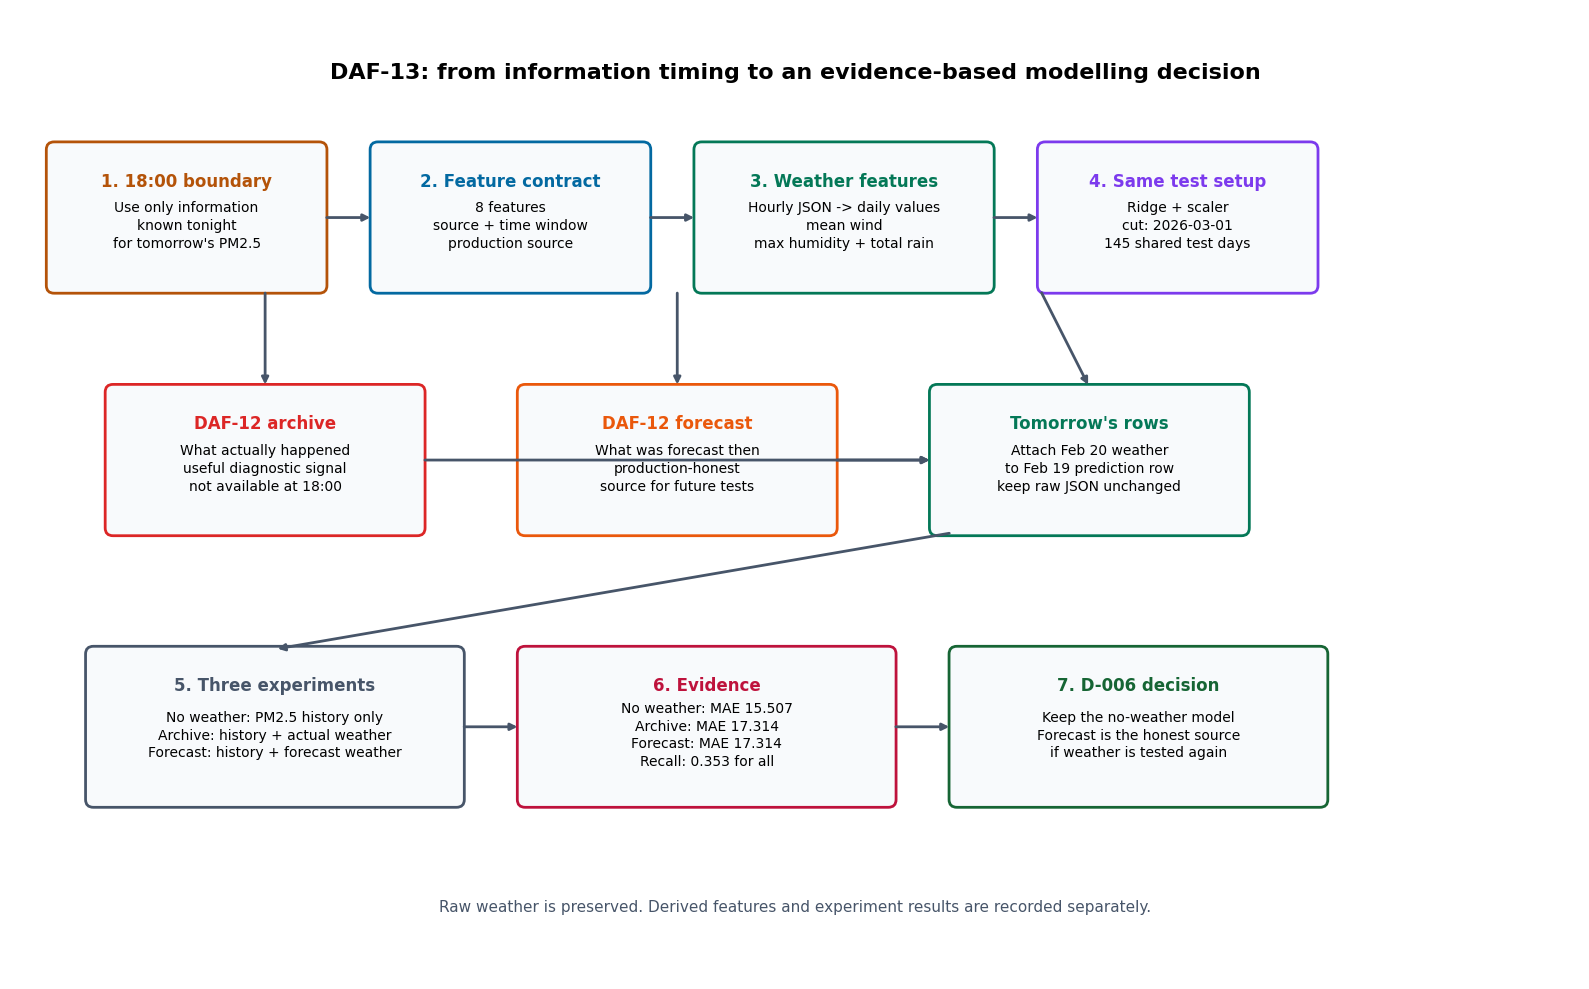

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")


def draw_box(x, y, width, height, title, body, color):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=2,
        edgecolor=color,
        facecolor="#f8fafc",
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height - 0.28,
        title,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold",
        color=color,
    )
    ax.text(
        x + width / 2,
        y + height / 2 - 0.08,
        body,
        ha="center",
        va="center",
        fontsize=10,
        linespacing=1.35,
    )


def connect(start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "-|>", "linewidth": 2, "color": "#475569"},
    )


draw_box(0.4, 7.1, 2.8, 1.5, "1. 18:00 boundary", "Use only information\nknown tonight\nfor tomorrow's PM2.5", "#b45309")
draw_box(3.7, 7.1, 2.8, 1.5, "2. Feature contract", "8 features\nsource + time window\nproduction source", "#0369a1")
draw_box(7.0, 7.1, 3.0, 1.5, "3. Weather features", "Hourly JSON -> daily values\nmean wind\nmax humidity + total rain", "#047857")
draw_box(10.5, 7.1, 2.8, 1.5, "4. Same test setup", "Ridge + scaler\ncut: 2026-03-01\n145 shared test days", "#7c3aed")
connect((3.2, 7.85), (3.7, 7.85))
connect((6.5, 7.85), (7.0, 7.85))
connect((10.0, 7.85), (10.5, 7.85))

draw_box(1.0, 4.6, 3.2, 1.5, "DAF-12 archive", "What actually happened\nuseful diagnostic signal\nnot available at 18:00", "#dc2626")
draw_box(5.2, 4.6, 3.2, 1.5, "DAF-12 forecast", "What was forecast then\nproduction-honest\nsource for future tests", "#ea580c")
draw_box(9.4, 4.6, 3.2, 1.5, "Tomorrow's rows", "Attach Feb 20 weather\nto Feb 19 prediction row\nkeep raw JSON unchanged", "#047857")
connect((2.6, 7.1), (2.6, 6.1))
connect((6.8, 7.1), (6.8, 6.1))
connect((4.2, 5.35), (9.4, 5.35))
connect((8.4, 5.35), (9.4, 5.35))

draw_box(0.8, 1.8, 3.8, 1.6, "5. Three experiments", "No weather: PM2.5 history only\nArchive: history + actual weather\nForecast: history + forecast weather", "#475569")
draw_box(5.2, 1.8, 3.8, 1.6, "6. Evidence", "No weather: MAE 15.507\nArchive: MAE 17.314\nForecast: MAE 17.314\nRecall: 0.353 for all", "#be123c")
draw_box(9.6, 1.8, 3.8, 1.6, "7. D-006 decision", "Keep the no-weather model\nForecast is the honest source\nif weather is tested again", "#166534")
connect((10.5, 7.1), (11.0, 6.1))
connect((9.6, 4.6), (2.7, 3.4))
connect((4.6, 2.6), (5.2, 2.6))
connect((9.0, 2.6), (9.6, 2.6))

ax.text(8.0, 9.35, "DAF-13: from information timing to an evidence-based modelling decision", ha="center", va="center", fontsize=16, fontweight="bold")
ax.text(8.0, 0.75, "Raw weather is preserved. Derived features and experiment results are recorded separately.", ha="center", va="center", fontsize=11, color="#475569")

fig.tight_layout()
display(fig)
plt.close(fig)

# Recap — Notebook 13 in one picture

The central question of this ticket is not only *"is this feature useful?"* but *"could the live service really know this value when it makes the prediction?"* This notebook writes that down as a feature contract, then tests three weather features on the same model. This notebook already ends with its own flow diagram. This recap adds the evidence behind it.

```text
18:00 boundary -> feature contract -> tomorrow's weather per day -> one controlled experiment -> the result -> decision D-006
  what is allowed    8 features          570 dates per source      none / archive / forecast     MAE 15.51 -> 17.31    keep no weather
```

**How to read the pictures**

- **Picture 1, the journey.** Seven cards follow the notebook. Underneath: the three experiment scores and the contract table.
- **Picture 2, the evidence.** The 18:00 boundary drawn on a timeline, one real example of how tomorrow's weather is attached to today's row, and how each input relates to tomorrow's PM2.5 in the training and the test periods.
- **Where the numbers come from.** The three experiments are refitted here with the notebook's exact settings, so they match its results. The correlation chart is an extra check made for this recap.

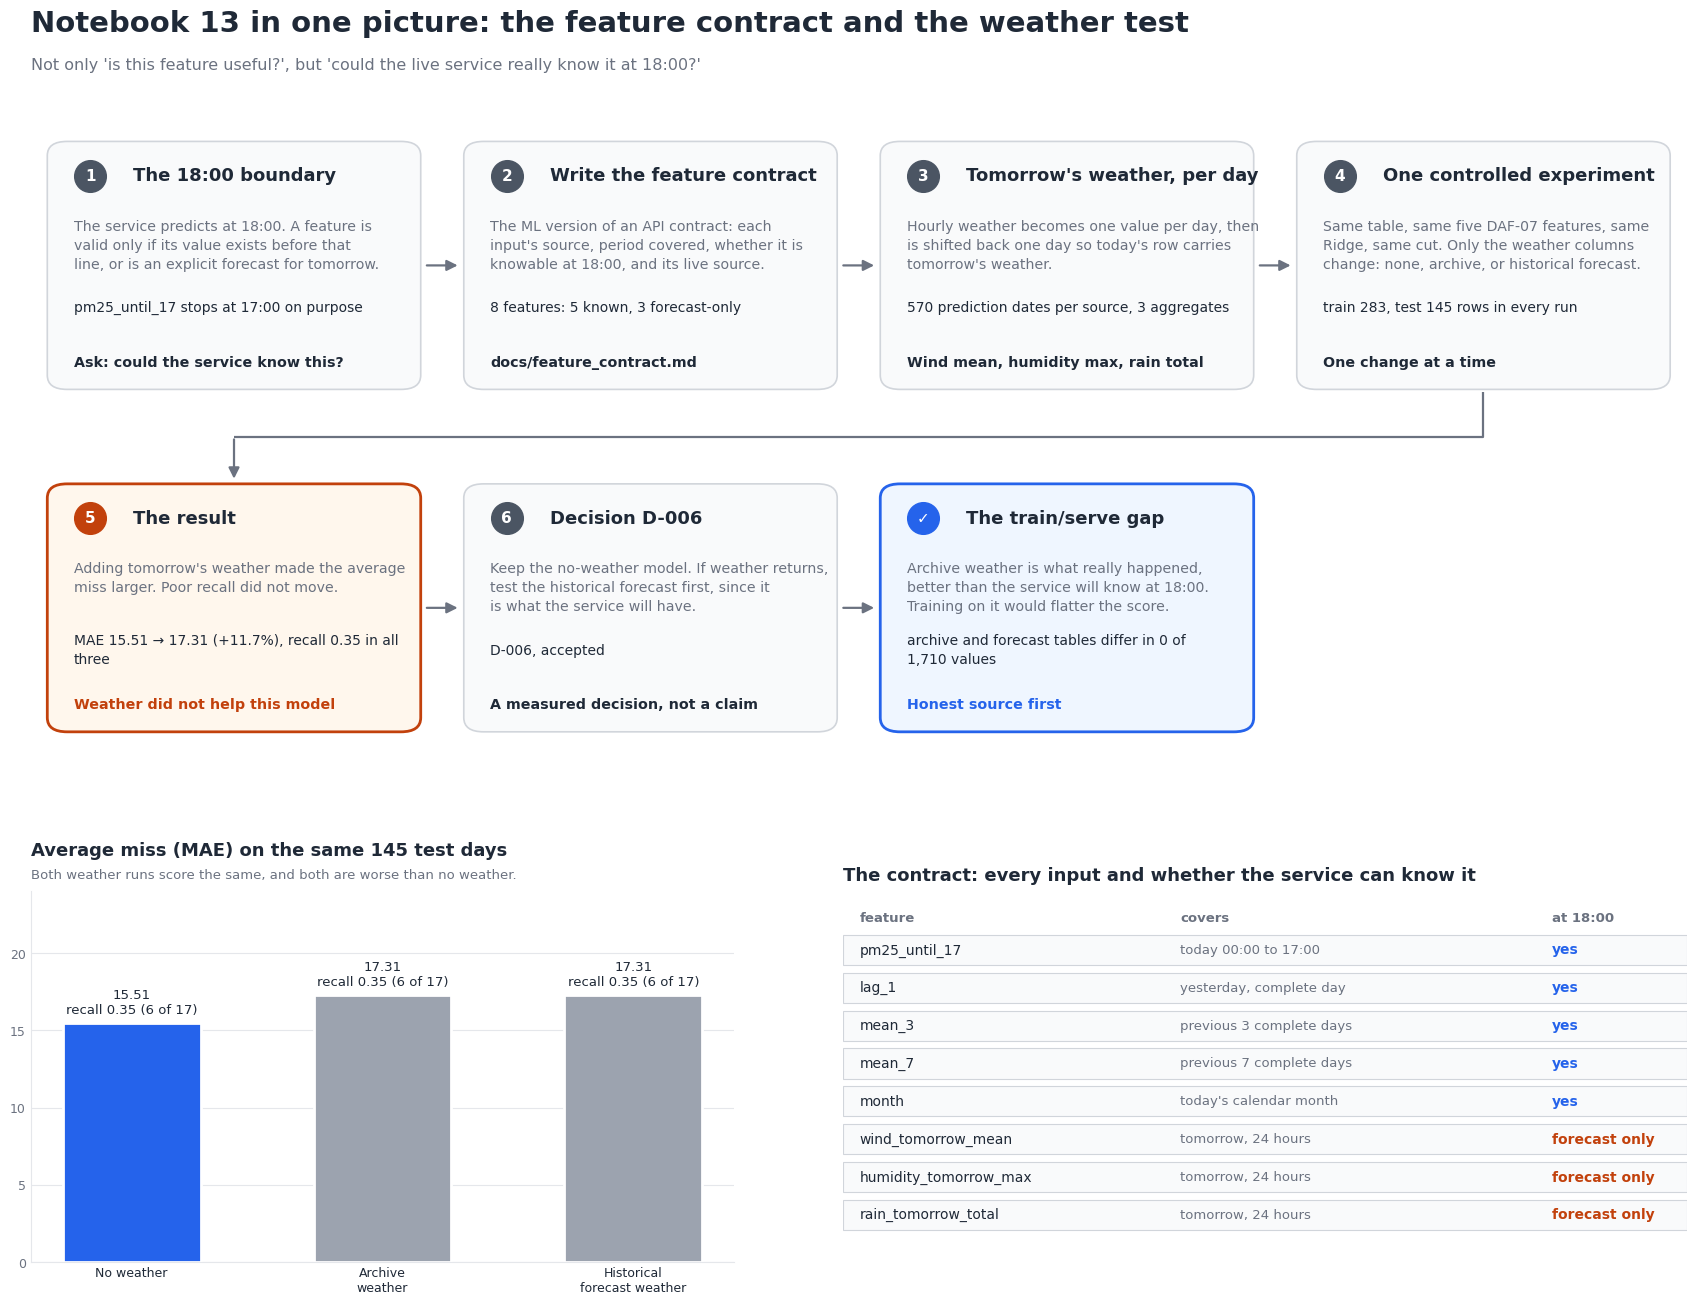

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import recap_style as rs

root = rs.find_project_root()
data_root = root / "data"
base_features = ["pm25_until_17", "lag_1", "mean_3", "mean_7", "month"]
weather_features = ["wind_tomorrow_mean", "humidity_tomorrow_max", "rain_tomorrow_total"]
cut_date = pd.Timestamp("2026-03-01")
poor_line = 91

daily = pd.read_csv(data_root / "interim/daily_17.csv", parse_dates=["date"], index_col="date")
daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None).normalize()
yesterday = daily["pm25_mean"].shift(1)
table = pd.DataFrame(index=daily.index)
table["pm25_until_17"], table["lag_1"] = daily["pm25_until_17"], yesterday
table["mean_3"], table["mean_7"] = yesterday.rolling(3).mean(), yesterday.rolling(7).mean()
table["month"], table["target"] = daily.index.month, daily["target"]


def weather(source):
    frame = pd.read_csv(data_root / f"interim/weather_features_{source}.csv", parse_dates=["prediction_date"], index_col="prediction_date")
    frame.index = frame.index.normalize()
    return frame[weather_features]


def experiment(source=None):
    columns = list(base_features)
    rows = table
    if source is not None:
        rows = table.join(weather(source), how="left")
        columns += weather_features
    rows = rows.dropna(subset=columns + ["target"])
    train, test = rows[rows.index < cut_date], rows[rows.index >= cut_date]
    pipe = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0, solver="lsqr"))])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        pipe.fit(train[columns], train["target"])
        guess = pipe.predict(test[columns])
    poor = test["target"] >= poor_line
    return dict(mae=mean_absolute_error(test["target"], guess), recall=recall_score(poor, guess >= poor_line, zero_division=0),
                caught=int((poor & (guess >= poor_line)).sum()), poor=int(poor.sum()), train=len(train), test=len(test)), train, test


no_weather, _, _ = experiment()
archive_result, train_w, test_w = experiment("archive")
forecast_result, _, _ = experiment("forecast")
archive_features, forecast_features = weather("archive"), weather("forecast")
feature_tables_differ = int(((archive_features - forecast_features).abs() > 1e-9).sum().sum())

worse = (archive_result["mae"] / no_weather["mae"] - 1) * 100
contract = [
    ("pm25_until_17", "today 00:00 to 17:00", "yes"), ("lag_1", "yesterday, complete day", "yes"), ("mean_3", "previous 3 complete days", "yes"),
    ("mean_7", "previous 7 complete days", "yes"), ("month", "today's calendar month", "yes"),
    ("wind_tomorrow_mean", "tomorrow, 24 hours", "forecast only"), ("humidity_tomorrow_max", "tomorrow, 24 hours", "forecast only"),
    ("rain_tomorrow_total", "tomorrow, 24 hours", "forecast only"),
]
contract_text = (root / "docs/feature_contract.md").read_text()
assert all(name in contract_text for name, _, _ in contract), "docs/feature_contract.md no longer lists the DAF-13 features"

cards = [
    dict(badge="1", title="The 18:00 boundary", adds="The service predicts at 18:00. A feature is valid only if its value exists before that line, or is an explicit forecast for tomorrow.",
         numbers="pm25_until_17 stops at 17:00 on purpose", verdict="Ask: could the service know this?"),
    dict(badge="2", title="Write the feature contract", adds="The ML version of an API contract: each input's source, period covered, whether it is knowable at 18:00, and its live source.",
         numbers="8 features: 5 known, 3 forecast-only", verdict="docs/feature_contract.md"),
    dict(badge="3", title="Tomorrow's weather, per day", adds="Hourly weather becomes one value per day, then is shifted back one day so today's row carries tomorrow's weather.",
         numbers=f"{len(archive_features)} prediction dates per source, 3 aggregates", verdict="Wind mean, humidity max, rain total"),
    dict(badge="4", title="One controlled experiment", adds="Same table, same five DAF-07 features, same Ridge, same cut. Only the weather columns change: none, archive, or historical forecast.",
         numbers=f"train {no_weather['train']}, test {no_weather['test']} rows in every run", verdict="One change at a time"),
    dict(badge="5", title="The result", adds="Adding tomorrow's weather made the average miss larger. Poor recall did not move.",
         numbers=f"MAE {no_weather['mae']:.2f} → {archive_result['mae']:.2f} ({worse:+.1f}%), recall {no_weather['recall']:.2f} in all three", verdict="Weather did not help this model", kind="problem"),
    dict(badge="6", title="Decision D-006", adds="Keep the no-weather model. If weather returns, test the historical forecast first, since it is what the service will have.",
         numbers="D-006, accepted", verdict="A measured decision, not a claim"),
    dict(badge="✓", title="The train/serve gap", adds="Archive weather is what really happened, better than the service will know at 18:00. Training on it would flatter the score.",
         numbers=f"archive and forecast tables differ in {feature_tables_differ} of {archive_features.size:,} values", verdict="Honest source first", kind="final"),
]

flow_h = rs.flow_size(len(cards), 4)
fig = plt.figure(figsize=(rs.FIG_W, flow_h + 5.2), facecolor="white")
grid = fig.add_gridspec(2, 2, height_ratios=[flow_h, 5.2], hspace=0.3, wspace=0.14, left=0.05, right=0.97, top=0.9, bottom=0.08, width_ratios=[1, 1.2])
rs.header(fig, "Notebook 13 in one picture: the feature contract and the weather test",
          "Not only 'is this feature useful?', but 'could the live service really know it at 18:00?'")
rs.draw_cards(fig.add_subplot(grid[0, :]), cards, cols=4)

scores = fig.add_subplot(grid[1, 0])
names = ["No weather", "Archive\nweather", "Historical\nforecast weather"]
results = [no_weather, archive_result, forecast_result]
bars = scores.bar(names, [r["mae"] for r in results], color=[rs.ACCENT, rs.BAR, rs.BAR], width=0.55, edgecolor="white", linewidth=2)
scores.set_ylim(0, 24)
for bar, r in zip(bars, results):
    scores.text(bar.get_x() + bar.get_width() / 2, r["mae"] + 0.4, f"{r['mae']:.2f}\nrecall {r['recall']:.2f} ({r['caught']} of {r['poor']})", ha="center", va="bottom", fontsize=9.5, color=rs.INK)
rs.style_axis(scores, "Average miss (MAE) on the same 145 test days", "Both weather runs score the same, and both are worse than no weather.")

box = fig.add_subplot(grid[1, 1])
box.set_xlim(0, 10)
box.set_ylim(len(contract) + 0.4, -1.4)
box.axis("off")
box.set_title("The contract: every input and whether the service can know it", loc="left", fontsize=13, fontweight="bold", color=rs.INK, pad=8)
for x, header in ((0.2, "feature"), (4.0, "covers"), (8.4, "at 18:00")):
    box.text(x, -0.7, header, fontsize=9.5, fontweight="bold", color=rs.MUTED, va="center")
for i, (name, covers, knowable) in enumerate(contract):
    y = i + 0.15
    known = knowable == "yes"
    box.add_patch(plt.Rectangle((0, y - 0.4), 10, 0.8, facecolor=rs.CARD_FILL, edgecolor=rs.CARD_EDGE, linewidth=0.8))
    box.text(0.2, y, name, va="center", fontsize=10, color=rs.INK)
    box.text(4.0, y, covers, va="center", fontsize=9.5, color=rs.MUTED)
    box.text(8.4, y, "yes" if known else "forecast only", va="center", fontsize=10, fontweight="bold", color=rs.ACCENT if known else rs.ALERT)
plt.show()

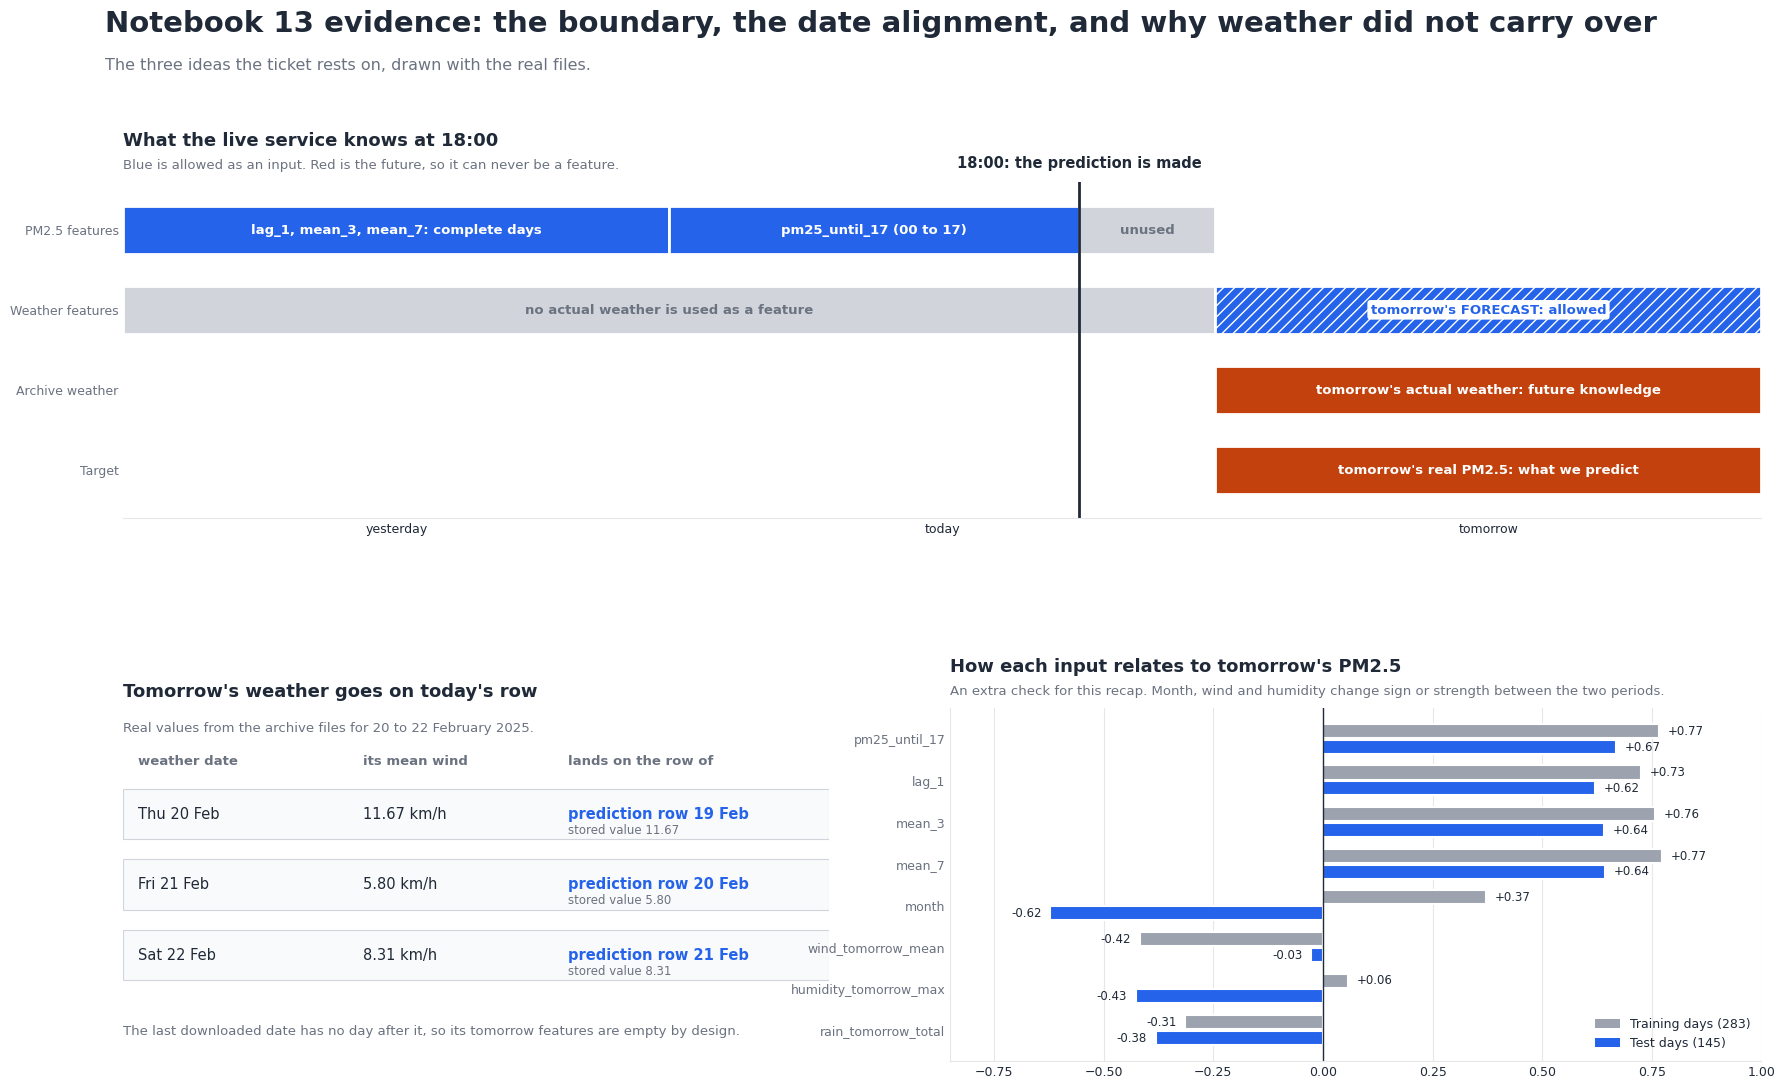

In [2]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import recap_style as rs

root = rs.find_project_root()
data_root = root / "data"
base_features = ["pm25_until_17", "lag_1", "mean_3", "mean_7", "month"]
weather_features = ["wind_tomorrow_mean", "humidity_tomorrow_max", "rain_tomorrow_total"]
cut_date = pd.Timestamp("2026-03-01")
poor_line = 91

daily = pd.read_csv(data_root / "interim/daily_17.csv", parse_dates=["date"], index_col="date")
daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None).normalize()
yesterday = daily["pm25_mean"].shift(1)
table = pd.DataFrame(index=daily.index)
table["pm25_until_17"], table["lag_1"] = daily["pm25_until_17"], yesterday
table["mean_3"], table["mean_7"] = yesterday.rolling(3).mean(), yesterday.rolling(7).mean()
table["month"], table["target"] = daily.index.month, daily["target"]


def weather(source):
    frame = pd.read_csv(data_root / f"interim/weather_features_{source}.csv", parse_dates=["prediction_date"], index_col="prediction_date")
    frame.index = frame.index.normalize()
    return frame[weather_features]


def experiment(source=None):
    columns = list(base_features)
    rows = table
    if source is not None:
        rows = table.join(weather(source), how="left")
        columns += weather_features
    rows = rows.dropna(subset=columns + ["target"])
    train, test = rows[rows.index < cut_date], rows[rows.index >= cut_date]
    pipe = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0, solver="lsqr"))])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        pipe.fit(train[columns], train["target"])
        guess = pipe.predict(test[columns])
    poor = test["target"] >= poor_line
    return dict(mae=mean_absolute_error(test["target"], guess), recall=recall_score(poor, guess >= poor_line, zero_division=0),
                caught=int((poor & (guess >= poor_line)).sum()), poor=int(poor.sum()), train=len(train), test=len(test)), train, test


no_weather, _, _ = experiment()
archive_result, train_w, test_w = experiment("archive")
forecast_result, _, _ = experiment("forecast")
archive_features, forecast_features = weather("archive"), weather("forecast")
feature_tables_differ = int(((archive_features - forecast_features).abs() > 1e-9).sum().sum())

raw_root = data_root / "raw/openmeteo/archive"
hourly = pd.concat([pd.DataFrame(json.loads(p.read_text(encoding="utf-8"))["hourly"]) for p in sorted(raw_root.glob("location-17-*.json"))], ignore_index=True)
hourly["time"] = pd.to_datetime(hourly["time"])
wind_by_day = hourly.groupby(hourly["time"].dt.normalize())["wind_speed_10m"].mean()

fig = plt.figure(figsize=(rs.FIG_W, 11.5), facecolor="white")
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.05], hspace=0.55, wspace=0.16, left=0.06, right=0.97, top=rs.top_margin(fig, 1.9), bottom=0.07, width_ratios=[1, 1.15])
rs.header(fig, "Notebook 13 evidence: the boundary, the date alignment, and why weather did not carry over",
          "The three ideas the ticket rests on, drawn with the real files.")

line = fig.add_subplot(grid[0, :])
line.set_xlim(0, 72)
line.set_ylim(-0.6, 3.6)
line.set_yticks([3, 2, 1, 0], ["PM2.5 features", "Weather features", "Archive weather", "Target"])
line.set_xticks([12, 36, 60], ["yesterday", "today", "tomorrow"], fontsize=10.5)
for spine in ("left", "top", "right"):
    line.spines[spine].set_visible(False)
line.spines["bottom"].set_color(rs.GRID)
line.tick_params(length=0, colors=rs.INK)
allowed, blocked, unused = rs.ACCENT, rs.ALERT, rs.CARD_EDGE


def segment(row, start, end, color, label, text_color="white", hatch=None, boxed=False):
    line.barh(row, end - start, left=start, height=0.6, color=color, edgecolor="white", linewidth=2, hatch=hatch)
    line.text((start + end) / 2, row, label, ha="center", va="center", fontsize=9.5, color=text_color, fontweight="bold",
              bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none") if boxed else None)


segment(3, 0, 24, allowed, "lag_1, mean_3, mean_7: complete days")
segment(3, 24, 42, allowed, "pm25_until_17 (00 to 17)")
segment(3, 42, 48, unused, "unused", rs.MUTED)
segment(2, 0, 48, unused, "no actual weather is used as a feature", rs.MUTED)
segment(2, 48, 72, allowed, "tomorrow's FORECAST: allowed", rs.ACCENT, hatch="///", boxed=True)
segment(1, 48, 72, blocked, "tomorrow's actual weather: future knowledge")
segment(0, 48, 72, blocked, "tomorrow's real PM2.5: what we predict")
line.axvline(42, color=rs.INK, linewidth=2)
line.text(42, 3.78, "18:00: the prediction is made", ha="center", fontsize=10.5, fontweight="bold", color=rs.INK)
rs.style_axis(line, "What the live service knows at 18:00", "Blue is allowed as an input. Red is the future, so it can never be a feature.", grid_axis=None)

align = fig.add_subplot(grid[1, 0])
align.set_xlim(0, 10)
align.set_ylim(5.6, -1.4)
align.axis("off")
align.set_title("Tomorrow's weather goes on today's row", loc="left", fontsize=13, fontweight="bold", color=rs.INK, pad=8)
align.text(0, -1.0, "Real values from the archive files for 20 to 22 February 2025.", fontsize=9.5, color=rs.MUTED, va="center")
days = pd.to_datetime(["2025-02-20", "2025-02-21", "2025-02-22"])
align.text(0.2, -0.35, "weather date", fontsize=9.5, fontweight="bold", color=rs.MUTED, va="center")
align.text(3.4, -0.35, "its mean wind", fontsize=9.5, fontweight="bold", color=rs.MUTED, va="center")
align.text(6.3, -0.35, "lands on the row of", fontsize=9.5, fontweight="bold", color=rs.MUTED, va="center")
for i, day in enumerate(days):
    y = i * 1.4 + 0.7
    target_day = day - pd.Timedelta(days=1)
    stored = archive_features.loc[target_day, "wind_tomorrow_mean"] if target_day in archive_features.index else np.nan
    align.add_patch(plt.Rectangle((0, y - 0.5), 10, 1.0, facecolor=rs.CARD_FILL, edgecolor=rs.CARD_EDGE, linewidth=0.8))
    align.text(0.2, y, day.strftime("%a %d %b"), va="center", fontsize=10.5, color=rs.INK)
    align.text(3.4, y, f"{wind_by_day.loc[day]:.2f} km/h", va="center", fontsize=10.5, color=rs.INK)
    align.text(6.3, y, f"prediction row {target_day.strftime('%d %b')}", va="center", fontsize=10.5, color=rs.ACCENT, fontweight="bold")
    align.text(6.3, y + 0.32, f"stored value {stored:.2f}" if not np.isnan(stored) else "no row before the first date", va="center", fontsize=8.5, color=rs.MUTED)
align.text(0, 5.0, f"The last downloaded date has no day after it, so its tomorrow features are empty by design.", fontsize=9.5, color=rs.MUTED, va="center")

names = base_features + weather_features
train_corr = train_w[names + ["target"]].corr()["target"].drop("target")
test_corr = test_w[names + ["target"]].corr()["target"].drop("target")
corr = fig.add_subplot(grid[1, 1])
y = np.arange(len(names))[::-1]
corr.barh(y + 0.19, train_corr.values, height=0.34, color=rs.BAR, edgecolor="white", linewidth=1.5)
corr.barh(y - 0.19, test_corr.values, height=0.34, color=rs.ACCENT, edgecolor="white", linewidth=1.5)
corr.axvline(0, color=rs.INK, linewidth=1)
corr.set_yticks(y, names, fontsize=9.5)
for i, name in enumerate(names):
    for offset, value in ((0.19, train_corr[name]), (-0.19, test_corr[name])):
        corr.text(value + (0.02 if value >= 0 else -0.02), y[i] + offset, f"{value:+.2f}", va="center", ha="left" if value >= 0 else "right", fontsize=8.5, color=rs.INK)
corr.set_xlim(-0.85, 1.0)
rs.legend(corr, [(f"Training days ({len(train_w)})", rs.BAR, "bar"), (f"Test days ({len(test_w)})", rs.ACCENT, "bar")], loc="lower right")
rs.style_axis(corr, "How each input relates to tomorrow's PM2.5", "An extra check for this recap. Month, wind and humidity change sign or strength between the two periods.", grid_axis="x")
plt.show()

### Recap in five lines

1. **A feature must be knowable at 18:00, or be an explicit forecast for tomorrow.** The contract writes that down for every input: its source, what it covers, whether the service can know it, and where production gets it.
2. **Tomorrow's weather goes on today's row.** Hourly weather becomes one value per day, then is shifted back one day. The last date has no tomorrow, by design.
3. **Change one thing at a time.** Same table, same five features, same Ridge, same cut date. The only difference between the three runs is the weather columns.
4. **Weather did not help this model.** MAE went from 15.51 to 17.31 (11.7% worse) with either source, and Poor recall stayed at 0.35. The extra check shows why it is plausible: wind and humidity relate to tomorrow's PM2.5 quite differently in the training months and the test months.
5. **Decision D-006:** keep the no-weather model. If weather returns, test the historical forecast first, because it is what the live service will have. Archive weather stays a diagnostic. This is a measured result, not a claim that weather can never help.

**If you remember only one thing:** an input that is better in training than it can ever be in production will flatter your score. The contract exists to stop that before it happens.